## Ensemble Models

In [7]:
# Import libraries
import keras # library for neural network. Need tensorflow to installed before performing this installation.
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.preprocessing import normalize 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [8]:
# Importing the dataset
X = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/X_preprocessed_10K_RemovedMorefeature_1.csv')
y = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/y_preprocessed_10K_RemovedMorefeature_1.csv')

In [9]:
# Check type
if isinstance(y, pd.Series):
    print("y is a Series")
elif isinstance(y, pd.DataFrame):
    print("y is a DataFrame")
else:
    print("y is neither a Series nor a DataFrame")

y is a DataFrame


In [10]:
# Convert the DataFrame to a Series
y= y.squeeze()

In [11]:
# Creating train,test and validation data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

print("Length of train set: ", X_train.shape, "y:", y_train.shape)
print("Length of test set: ", X_test.shape, "y:", y_test.shape)

Length of train set:  (16728, 25) y: (16728,)
Length of test set:  (4182, 25) y: (4182,)


AdaBoost Classifier

In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the AdaBoostClassifier
ada_boost = AdaBoostClassifier(algorithm='SAMME')

# Define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [20, 50, 70, 100],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3],
    'random_state': [2, 4, 6, 8, 10]
}

# Perform Grid Search
gs_ada = GridSearchCV(estimator=ada_boost, param_grid=parameters, scoring='accuracy', cv=10, verbose=1)
gs_ada.fit(X_train, y_train)

# Get the best parameters and score
best_parameters = gs_ada.best_params_
best_score = gs_ada.best_score_
print("Best Parameters:", best_parameters)
print("Best Score:", best_score)

# Predict on test data
y_pred = gs_ada.predict(X_test)

# Get the accuracy score
ada_acc = accuracy_score(y_test, y_pred)
ada_pre = precision_score(y_test, y_pred, average='micro')
ada_recall = recall_score(y_test, y_pred, average='micro')
ada_f1 = f1_score(y_test, y_pred, average='micro')

# Get the macro F1 score
ada_macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Adaboost - Accuracy: {:.3f}.".format(ada_acc))
print("Adaboost - Precision: {:.3f}.".format(ada_pre))
print("Adaboost - Recall: {:.3f}.".format(ada_recall))
print("Adaboost - F1_Score: {:.3f}.".format(ada_f1))
print("Adaboost - Macro F1_Score: {:.3f}.".format(ada_macro_f1))



Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Best Parameters: {'learning_rate': 0.3, 'n_estimators': 100, 'random_state': 2}
Best Score: 0.6039570564867857
Adaboost - Accuracy: 0.592.
Adaboost - Precision: 0.592.
Adaboost - Recall: 0.592.
Adaboost - F1_Score: 0.592.
Adaboost - Macro F1_Score: 0.598.



Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.72      0.60      1394
           1       0.46      0.46      0.46      1353
           2       0.97      0.60      0.74      1435

    accuracy                           0.59      4182
   macro avg       0.65      0.59      0.60      4182
weighted avg       0.65      0.59      0.60      4182


Confusion Matrix:
 [[1003  379   12]
 [ 727  616   10]
 [ 246  334  855]]


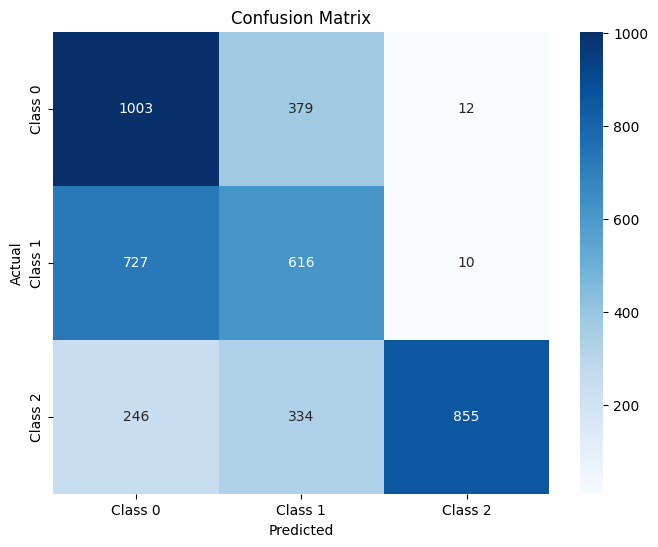

In [13]:
# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Gradient Boosting Classifier

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the GradientBoostingClassifier
GB = GradientBoostingClassifier()

# Define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3],
    'loss': ['log_loss'],  # Removed 'exponential' as it is for binary classification
    'criterion': ['squared_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2']
}

# Perform Grid Search
GB_SE = GridSearchCV(estimator=GB, param_grid=parameters, scoring='accuracy', cv=10, verbose=1)
GB_SE.fit(X_train, y_train)
best_parameters = GB_SE.best_params_
best_score = GB_SE.best_score_
print("Best Parameters:", best_parameters)
print("Best Score:", best_score)

# Predict on test data
y_pred = GB_SE.predict(X_test)

# Get the accuracy score
GB_acc = accuracy_score(y_test, y_pred)
GB_pre = precision_score(y_test, y_pred, average='micro')
GB_recall = recall_score(y_test, y_pred, average='micro')
GB_f1 = f1_score(y_test, y_pred, average='micro')

# Get the macro F1 score
GB_macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Gradient boost - Accuracy: {:.3f}.".format(GB_acc))
print("Gradient boost - Precision: {:.3f}.".format(GB_pre))
print("Gradient boost - Recall: {:.3f}.".format(GB_recall))
print("Gradient boost - F1_Score: {:.3f}.".format(GB_f1))
print("Gradient boost - Macro F1_Score: {:.3f}.".format(GB_macro_f1))

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 72 candidates, totalling 720 fits


C:\Users\sgk62\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'criterion': 'squared_error', 'learning_rate': 0.3, 'loss': 'log_loss', 'max_features': 'sqrt', 'n_estimators': 300}
Best Score: 0.8758968074427225
Gradient boost - Accuracy: 0.874.
Gradient boost - Precision: 0.874.
Gradient boost - Recall: 0.874.
Gradient boost - F1_Score: 0.874.
Gradient boost - Macro F1_Score: 0.875.

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86      1394
           1       0.88      0.87      0.88      1353
           2       0.93      0.86      0.89      1435

    accuracy                           0.87      4182
   macro avg       0.88      0.87      0.87      4182
weighted avg       0.88      0.87      0.87      4182




Confusion Matrix:
 [[1245   95   54]
 [ 135 1176   42]
 [ 137   62 1236]]


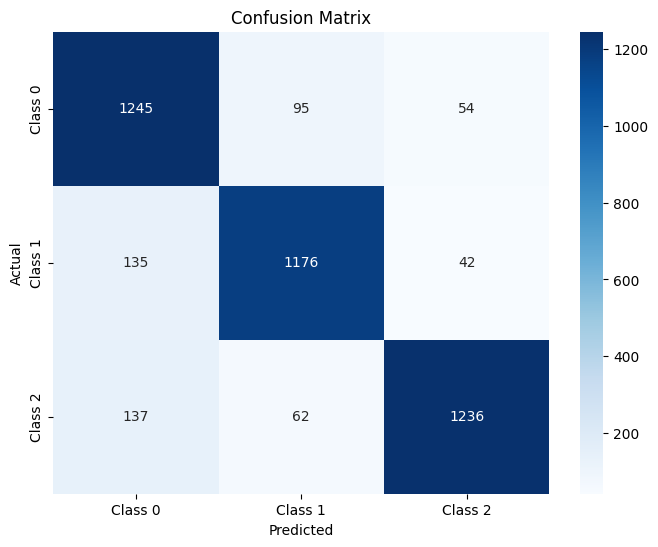

In [15]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Bagging Classifier

In [16]:
from sklearn.ensemble import BaggingClassifier

# Initialize the BaggingClassifier
bagging = BaggingClassifier()  # Base estimator is a DecisionTreeClassifier by default. Can use any suitable ML model.

# Define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [10, 20, 30, 40, 50],
    'max_samples': [1, 2, 3, 4, 5],
    'max_features': [1, 2, 3, 4, 5],
}

# Perform Grid Search
bagging_SE = GridSearchCV(estimator=bagging, param_grid=parameters, scoring='accuracy', cv=10, verbose=1)
bagging_SE.fit(X_train, y_train)

# Get the best parameters and score
best_parameters = bagging_SE.best_params_
best_score = bagging_SE.best_score_
print("Best Parameters:", best_parameters)
print("Best Score:", best_score)

# Predict on test data
y_pred = bagging_SE.predict(X_test)

# Get the accuracy score
bagging_acc = accuracy_score(y_test, y_pred)
bagging_pre = precision_score(y_test, y_pred, average='micro')
bagging_recall = recall_score(y_test, y_pred, average='micro')
bagging_f1 = f1_score(y_test, y_pred, average='micro')

# Get the macro F1 score
bagging_macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Bagging - Accuracy: {:.3f}.".format(bagging_acc))
print("Bagging - Precision: {:.3f}.".format(bagging_pre))
print("Bagging - Recall: {:.3f}.".format(bagging_recall))
print("Bagging - F1_Score: {:.3f}.".format(bagging_f1))
print("Bagging - Macro F1_Score: {:.3f}.".format(bagging_macro_f1))

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))




Fitting 10 folds for each of 125 candidates, totalling 1250 fits
Best Parameters: {'max_features': 5, 'max_samples': 5, 'n_estimators': 30}
Best Score: 0.5141666690499547
Bagging - Accuracy: 0.480.
Bagging - Precision: 0.480.
Bagging - Recall: 0.480.
Bagging - F1_Score: 0.480.
Bagging - Macro F1_Score: 0.420.

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.48      0.48      1394
           1       0.39      0.10      0.16      1353
           2       0.49      0.84      0.62      1435

    accuracy                           0.48      4182
   macro avg       0.45      0.47      0.42      4182
weighted avg       0.46      0.48      0.42      4182




Confusion Matrix:
 [[ 670  164  560]
 [ 538  135  680]
 [ 187   47 1201]]


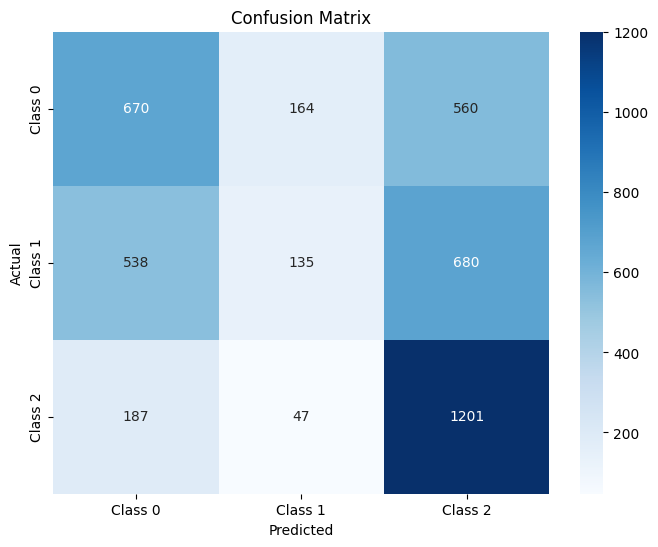

In [17]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Extra Trees Classifier

In [18]:
from sklearn.ensemble import ExtraTreesClassifier


# Initialize the ExtraTreesClassifier
ext = ExtraTreesClassifier()

# Define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [100, 200, 300, 400, 500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': ['sqrt', 'log2'],
}

# Perform Grid Search
ext_SE = GridSearchCV(estimator=ext, param_grid=parameters, scoring='accuracy', cv=10, verbose=1)
ext_SE.fit(X_train, y_train)
best_parameters = ext_SE.best_params_
best_score = ext_SE.best_score_
print("Best Parameters:", best_parameters)
print("Best Score:", best_score)

# Predict on test data
y_pred = ext_SE.predict(X_test)

# Get the accuracy score
ext_acc = accuracy_score(y_test, y_pred)
ext_pre = precision_score(y_test, y_pred, average='micro')
ext_recall = recall_score(y_test, y_pred, average='micro')
ext_f1 = f1_score(y_test, y_pred, average='micro')

# Get the macro F1 score
ext_macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Extra Trees - Accuracy: {:.3f}.".format(ext_acc))
print("Extra Trees - Precision: {:.3f}.".format(ext_pre))
print("Extra Trees - Recall: {:.3f}.".format(ext_recall))
print("Extra Trees - F1_Score: {:.3f}.".format(ext_f1))
print("Extra Trees - Macro F1_Score: {:.3f}.".format(ext_macro_f1))

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 30 candidates, totalling 300 fits


C:\Users\sgk62\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'criterion': 'log_loss', 'max_features': 'sqrt', 'n_estimators': 300}
Best Score: 0.8793042181337711
Extra Trees - Accuracy: 0.873.
Extra Trees - Precision: 0.873.
Extra Trees - Recall: 0.873.
Extra Trees - F1_Score: 0.873.
Extra Trees - Macro F1_Score: 0.874.

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85      1394
           1       0.92      0.87      0.90      1353
           2       0.93      0.83      0.88      1435

    accuracy                           0.87      4182
   macro avg       0.88      0.87      0.87      4182
weighted avg       0.88      0.87      0.87      4182




Confusion Matrix:
 [[1280   49   65]
 [ 145 1180   28]
 [ 190   54 1191]]


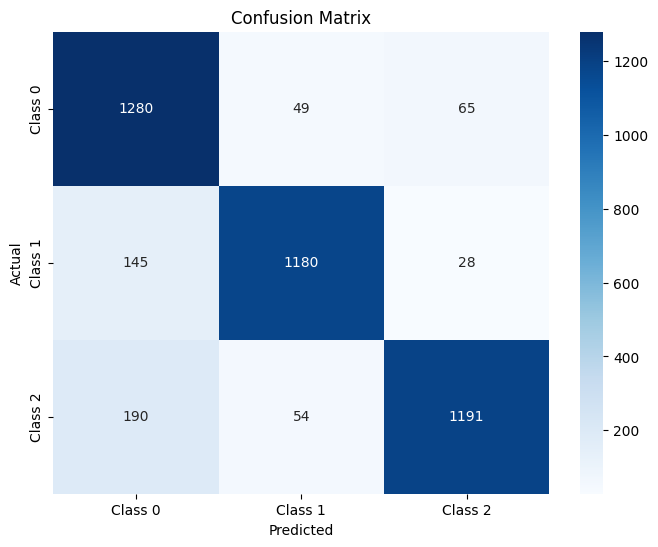

In [19]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Stacking Classifier

In [20]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

# Define the individual classifiers
AB = AdaBoostClassifier(algorithm='SAMME', learning_rate=0.3, n_estimators=100, random_state=2)
GB = GradientBoostingClassifier(criterion='squared_error', learning_rate=0.1, loss='log_loss', max_features='sqrt', n_estimators=300)
XGB = XGBClassifier(colsample_bytree=0.7, gamma=0.2, max_depth=3, min_child_weight=5, reg_alpha=0.05, subsample=0.8)
EXT = ExtraTreesClassifier(criterion='entropy', max_features='sqrt', n_estimators=100)

# Define the estimators for stacking
estimators = [
    ('Ada Boost', AB),
    ('Gradient Boost', GB),
    ('Xtreme Boost', XGB),
    ('Extra Trees', EXT)
]

# Initialize the StackingClassifier
stc = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=10, verbose=1)
stc.fit(X_train, y_train)

# Predict on test data
y_pred = stc.predict(X_test)

# Get the accuracy score
stc_acc = accuracy_score(y_test, y_pred)
stc_pre = precision_score(y_test, y_pred, average='micro')
stc_recall = recall_score(y_test, y_pred, average='micro')
stc_f1 = f1_score(y_test, y_pred, average='micro')

# Get the macro F1 score
stc_macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Stacking - Accuracy: {:.3f}.".format(stc_acc))
print("Stacking - Precision: {:.3f}.".format(stc_pre))
print("Stacking - Recall: {:.3f}.".format(stc_recall))
print("Stacking - F1_Score: {:.3f}.".format(stc_f1))
print("Stacking - Macro F1_Score: {:.3f}.".format(stc_macro_f1))

# Print detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Stacking - Accuracy: 0.886.
Stacking - Precision: 0.886.
Stacking - Recall: 0.886.
Stacking - F1_Score: 0.886.
Stacking - Macro F1_Score: 0.886.

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1394
           1       0.91      0.89      0.90      1353
           2       0.91      0.87      0.89      1435

    accuracy                           0.89      4182
   macro avg       0.89      0.89      0.89      4182
weighted avg       0.89      0.89      0.89      4182




Confusion Matrix:
 [[1251   62   81]
 [ 101 1210   42]
 [ 139   52 1244]]


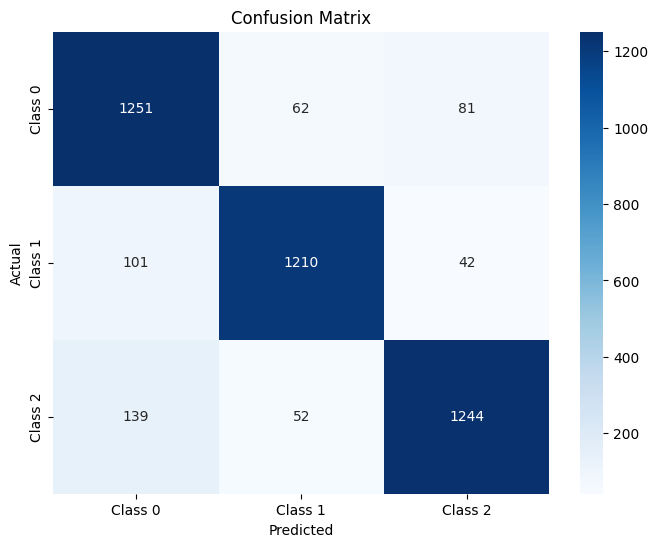

In [21]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

XGB Classifier with RandomizedSearchCV

In [22]:
# Import necessary libraries
# pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Instantiate the XGBoost Classifier
XGB = XGBClassifier()

# Define the parameter grid
parameters = {
    'max_depth': range(3, 10, 2),
    'min_child_weight': range(1, 6, 2),
    'gamma': [i/10.0 for i in range(0, 5)],
    'subsample': [i/10.0 for i in range(6, 10)],
    'colsample_bytree': [i/10.0 for i in range(6, 10)],
    'reg_alpha': [0, 0.001, 0.005, 0.01, 0.05],
}

# Use RandomizedSearchCV instead of GridSearchCV
XGB_SE = RandomizedSearchCV(estimator=XGB, param_distributions=parameters, scoring='accuracy', cv=10, n_iter=50, verbose=1, random_state=1, n_jobs=-1)
XGB_SE.fit(X_train, y_train)

# Extract the best parameters and score
best_parameters = XGB_SE.best_params_
best_score = XGB_SE.best_score_
print("Best Parameters:", best_parameters)
print("Best Score:", best_score)

# Predict on test data
y_pred = XGB_SE.predict(X_test)

# Calculate metrics on test data
XGB_acc = accuracy_score(y_test, y_pred)
XGB_pre = precision_score(y_test, y_pred, average='micro')
XGB_recall = recall_score(y_test, y_pred, average='micro')
XGB_f1 = f1_score(y_test, y_pred, average='micro')

print("\nXGB - Accuracy: {:.3f}.".format(XGB_acc))
print("XGB - Precision: {:.3f}.".format(XGB_pre))
print("XGB - Recall: {:.3f}.".format(XGB_recall))
print("XGB - F1_Score: {:.3f}.".format(XGB_f1))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best Parameters: {'subsample': 0.8, 'reg_alpha': 0.005, 'min_child_weight': 1, 'max_depth': 9, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best Score: 0.9131999001878983

XGB - Accuracy: 0.912.
XGB - Precision: 0.912.
XGB - Recall: 0.912.
XGB - F1_Score: 0.912.

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.90      1394
           1       0.94      0.91      0.92      1353
           2       0.94      0.90      0.92      1435

    accuracy                           0.91      4182
   macro avg       0.91      0.91      0.91      4182
weighted avg       0.91      0.91      0.91      4182




Confusion Matrix:
 [[1300   44   50]
 [  99 1227   27]
 [ 108   38 1289]]


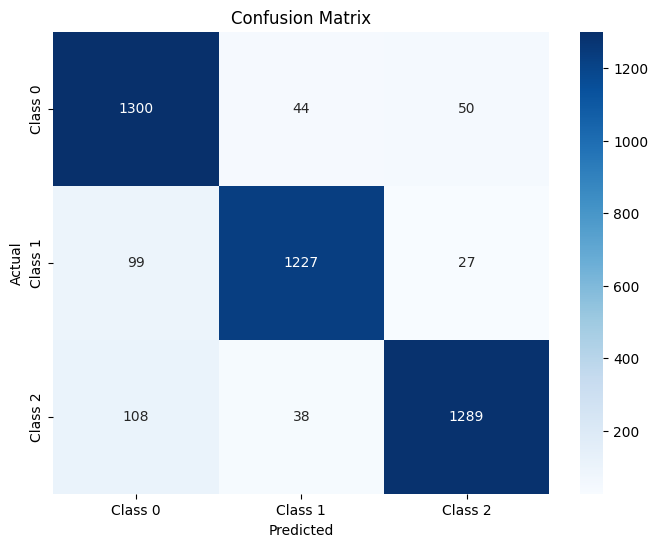

In [23]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()